In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load your two datasets
df_purchase = pd.read_csv("User_product_purchase_details_p2.csv")
df_user = pd.read_csv("user_demographics.csv")

In [3]:
df = pd.merge(df_purchase, df_user, on="User_ID", how="left")

In [4]:
# Create binary target
df["High_Value_Purchase"] = (df["Purchase"] >= 10000).astype(int)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
# Drop columns not needed
# keep Product categories because they might be predictive; drop Product_ID as requested
df = df.drop(["Product_ID"], axis=1)

In [7]:
# Replace missing (simple strategy: for categories use a placeholder, for numeric use 0)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].fillna("Missing")
    else:
        df[col] = df[col].fillna(0)

In [8]:
# Encode categorical variables using get_dummies
# Choose a set of columns likely categorical:
categorical_cols = ["Gender", "Age", "City_Category", "Stay_In_Current_City_Years", "Marital_Status"]
# Some Product_Category columns might be numeric but contain NaNs — keep them as numeric
df_encoded = pd.get_dummies(df, columns=[c for c in categorical_cols if c in df.columns], drop_first=True)

In [9]:
# Prepare X and y
X = df_encoded.drop(["High_Value_Purchase", "Purchase", "User_ID"], axis=1)
y = df_encoded["High_Value_Purchase"]


In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [11]:
# Scale numerical features
scaler = StandardScaler()
# Fit scaler on training set and transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log = LogisticRegression(max_iter=2000)
log.fit(X_train_scaled, y_train)
pred_lr = log.predict(X_test_scaled)

In [13]:
print("LR Accuracy:", accuracy_score(y_test, pred_lr))
print("LR Confusion Matrix:\n", confusion_matrix(y_test, pred_lr))
print("LR Classification Report:\n", classification_report(y_test, pred_lr))

LR Accuracy: 0.7661752140636646
LR Confusion Matrix:
 [[64702  7404]
 [18320 19588]]
LR Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.83     72106
           1       0.73      0.52      0.60     37908

    accuracy                           0.77    110014
   macro avg       0.75      0.71      0.72    110014
weighted avg       0.76      0.77      0.75    110014



In [14]:
# --- Simple feature importance extraction from Logistic Regression ---
feature_names = X.columns
coefs = pd.Series(log.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
print("Top 10 features by absolute coefficient (logistic regression):")
print(coefs.head(10))

Top 10 features by absolute coefficient (logistic regression):
Product_Category_1   -0.845970
Product_Category_3    0.430037
Gender_M              0.110769
City_Category_C       0.109819
Age_36-45             0.076448
Age_26-35             0.072334
Age_51-55             0.064008
Age_46-50             0.043494
City_Category_B       0.036939
Age_18-25             0.036241
dtype: float64


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import History

In [27]:
model = Sequential()

model.add(Dense(6, activation='relu', kernel_initializer='uniform', 
                input_shape=(X_train_scaled.shape[1],)))

model.add(Dense(6, activation='relu', kernel_initializer='uniform'))

model.add(Dense(1, activation='sigmoid', kernel_initializer='uniform'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['precision'])


In [28]:
# Fit the model
history = model.fit(X_train_scaled, y_train, epochs=15, batch_size=32, validation_split=0.1, verbose=2)

loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("MLP Accuracy:", acc)

Epoch 1/15
12377/12377 - 11s - 912us/step - loss: 0.4109 - precision: 0.7780 - val_loss: 0.3833 - val_precision: 0.7793
Epoch 2/15
12377/12377 - 11s - 855us/step - loss: 0.3769 - precision: 0.7757 - val_loss: 0.3718 - val_precision: 0.7684
Epoch 3/15
12377/12377 - 11s - 861us/step - loss: 0.3707 - precision: 0.7688 - val_loss: 0.3666 - val_precision: 0.7660
Epoch 4/15
12377/12377 - 10s - 832us/step - loss: 0.3656 - precision: 0.7723 - val_loss: 0.3616 - val_precision: 0.7690
Epoch 5/15
12377/12377 - 12s - 934us/step - loss: 0.3625 - precision: 0.7720 - val_loss: 0.3612 - val_precision: 0.7711
Epoch 6/15
12377/12377 - 10s - 846us/step - loss: 0.3536 - precision: 0.7730 - val_loss: 0.3479 - val_precision: 0.7726
Epoch 7/15
12377/12377 - 11s - 861us/step - loss: 0.3460 - precision: 0.7753 - val_loss: 0.3448 - val_precision: 0.7755
Epoch 8/15
12377/12377 - 10s - 829us/step - loss: 0.3448 - precision: 0.7778 - val_loss: 0.3451 - val_precision: 0.7758
Epoch 9/15
12377/12377 - 10s - 801us/ste

In [29]:
# Compare simple metrics
from sklearn.metrics import accuracy_score
pred_mlp_probs = model.predict(X_test_scaled)
pred_mlp = (pred_mlp_probs.flatten() >= 0.5).astype(int)

print("MLP Confusion Matrix:\n", confusion_matrix(y_test, pred_mlp))
print("MLP Classification Report:\n", classification_report(y_test, pred_mlp))

3438/3438 ━━━━━━━━━━━━━━━━━━━━ 2s 555us/step
MLP Confusion Matrix:
 [[62412  9694]
 [ 3163 34745]]
MLP Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91     72106
           1       0.78      0.92      0.84     37908

    accuracy                           0.88    110014
   macro avg       0.87      0.89      0.88    110014
weighted avg       0.89      0.88      0.88    110014



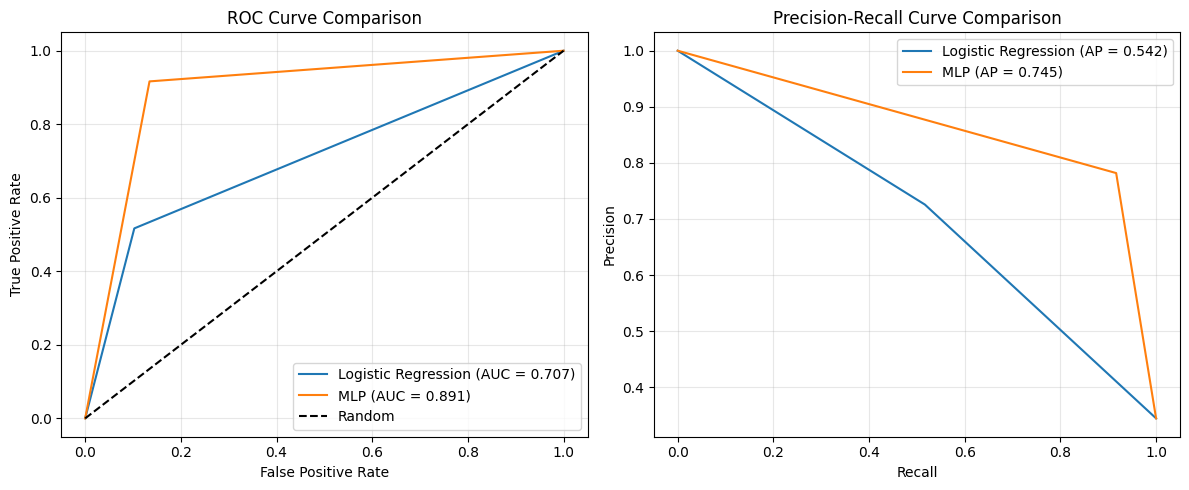

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# -------------------------
# ROC calculations
# -------------------------
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, pred_mlp)

auc_lr = roc_auc_score(y_test, pred_lr)
auc_mlp = roc_auc_score(y_test, pred_mlp)

# -------------------------
# Precision–Recall calculations
# -------------------------
precision_lr, recall_lr, _ = precision_recall_curve(y_test, pred_lr)
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, pred_mlp)

ap_lr = average_precision_score(y_test, pred_lr)
ap_mlp = average_precision_score(y_test, pred_mlp)

# -------------------------
# PLOT: ROC curves
# -------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc_mlp:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

# -------------------------
# PLOT: Precision-Recall curves
# -------------------------
plt.subplot(1, 2, 2)
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})')
plt.plot(recall_mlp, precision_mlp, label=f'MLP (AP = {ap_mlp:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
